# HIFtool UTAL — HARVARD Dataset Evaluation

In [1]:
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install imgvision einops scipy --no-deps -q
!git clone https://github.com/Nikesh0907/HIFtool.git /kaggle/working/HIFtool 2>/dev/null || true

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 101.6 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 64.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 44.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 33.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━

In [2]:
import os, sys, glob, argparse, time
import numpy as np, torch, torch.nn as nn
import scipy.io as sio, torch.utils.data as data
import matplotlib.pyplot as plt, imgvision as iv

HIFTOOL_DIR = '/kaggle/working/HIFtool'
sys.path.insert(0, HIFTOOL_DIR)

device = 'cpu'
if torch.cuda.is_available():
    try:
        x = torch.randn(1,1,4,4).cuda()
        torch.nn.functional.interpolate(x, scale_factor=2, mode='bilinear')
        device = 'cuda'
        print(f'GPU OK: {torch.cuda.get_device_name()}')
    except Exception as e:
        print(f'GPU broken ({e}), using CPU')
else:
    print('No GPU, using CPU')
print(f'Device: {device}  |  PyTorch: {torch.__version__}')

DATA_ROOT = '/kaggle/input/harvard-hsi-2/Data'
CKPT_PATH = sorted(glob.glob('/kaggle/input/models/**/*.pth', recursive=True))[0]

all_mat = sorted(glob.glob(os.path.join(DATA_ROOT, '**', '*.mat'), recursive=True))
test_mats = [f for f in all_mat if '/Test/HSI/' in f]
print(f'Test HSI files: {len(test_mats)}')
print(f'Checkpoint: {CKPT_PATH}')

GPU OK: Tesla T4
Device: cuda  |  PyTorch: 2.4.1+cu121
Test HSI files: 20
Checkpoint: /kaggle/input/model-utal/pytorch/default/1/1200.pth


In [3]:
def load_hsi(filepath):
    try:
        d = sio.loadmat(filepath)
    except NotImplementedError:
        import h5py
        with h5py.File(filepath, 'r') as f:
            d = {k: np.array(f[k]) for k in f.keys()}
    if 'hsi' in d: gt = d['hsi'].astype(np.float64)
    elif 'HSI' in d: gt = d['HSI'].astype(np.float64)
    else:
        arrays = {k:v for k,v in d.items() if not k.startswith('__') and hasattr(v,'shape') and v.ndim>=2}
        gt = max(arrays.values(), key=lambda v: v.size).astype(np.float64)
    if gt.ndim == 3 and gt.shape[0] <= 31 and gt.shape[2] > 31:
        gt = gt.transpose(1, 2, 0)
    if gt.max() > 1.0: gt = gt / gt.max()
    return gt

if test_mats:
    sample = load_hsi(test_mats[0])
    print(f'Verified: {os.path.basename(test_mats[0])} -> {sample.shape} ✓')

Verified: imga5.mat -> (1040, 1392, 31) ✓


In [4]:
from Networks.UTAL.net import ThreeBranch_Net

opt = argparse.Namespace(
    sf=32, msi_channel=3, hsi_channel=31, h_size=[512, 512],
    Depth=3, KS_1=3, KS_2=3, KS_3=3,
    pre_srf=os.path.join(HIFTOOL_DIR, 'Networks/UTAL/knowledge/P_N_V2.mat'),
    pre_srf_key='P', fusion_model_path=CKPT_PATH,
    save_path='UTAL/harvard/meta', save_path_specific='',
)

model = ThreeBranch_Net(opt, device).to(device)
print(f'UTAL params: {sum(p.numel() for p in model.parameters()):,}')

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
sd = ckpt.get('net', ckpt) if isinstance(ckpt, dict) else ckpt
sd = {k.replace('module.', ''): v for k, v in sd.items()}
m, u = model.load_state_dict(sd, strict=False)
print(f'Loaded | missing:{len(m)} unexpected:{len(u)}')
if m: print(f'  Missing: {m[:5]}')
if u: print(f'  Unexpected: {u[:5]}')
model.eval()
print(f'UTAL ready on {device} ✓')

UTAL params: 7,097,695
Loaded | missing:0 unexpected:0
UTAL ready on cuda ✓


In [5]:
def getGk(ksize, sigma):
    x = torch.arange(-(ksize-1)//2, (ksize-1)//2+1)
    k = torch.exp(-0.5*(x/sigma)**2); k /= k.sum()
    return k.view(-1, 1).float()

class SpaDown(nn.Module):
    def __init__(self, sf):
        super().__init__()
        k = getGk(sf, sf/1.5); k = k @ k.T
        self.down = nn.Conv2d(1, 1, sf, sf, bias=False)
        self.down.weight.data[0, 0] = k
        self.down.requires_grad_(False)
    def forward(self, x):
        return self.down(x.transpose(1, 0)).transpose(1, 0)

SRF = np.load(os.path.join(HIFTOOL_DIR, 'Dataloader_tool', 'srflib', 'NikonD700.npy'))
print(f'SRF: {SRF.shape}')

class HarvardDataset(data.Dataset):
    def __init__(self, mat_paths, sf, srf):
        self.HR, self.LR, self.MSI, self.names = [], [], [], []
        sp = SpaDown(sf)
        for fp in mat_paths:
            gt = load_hsi(fp)
            gt31 = gt[:, :, :srf.shape[0]]
            h, w = gt31.shape[:2]
            gt31 = gt31[:h - (h % sf), :w - (w % sf), :]
            lr = sp(torch.tensor(gt31.T).unsqueeze(0).float())[0].permute(2, 1, 0).numpy()
            msi = gt31 @ srf
            self.HR.append(gt31); self.LR.append(lr); self.MSI.append(msi)
            self.names.append(os.path.splitext(os.path.basename(fp))[0])
            print(f'  {self.names[-1]}: {gt31.shape}')
    def __getitem__(self, i):
        return (torch.FloatTensor(self.HR[i].transpose(2,0,1)),
                torch.FloatTensor(self.LR[i].transpose(2,0,1)),
                torch.FloatTensor(self.MSI[i].transpose(2,0,1)))
    def __len__(self): return len(self.HR)

print(f'Building dataset from {len(test_mats)} HSI files...')
ds = HarvardDataset(test_mats, opt.sf, SRF)
loader = data.DataLoader(ds, batch_size=1, shuffle=False)
print(f'Dataset: {len(ds)} images ✓')

SRF: (31, 3)
Building dataset from 20 HSI files...
  imga5: (1024, 1376, 31)
  imga7: (1024, 1376, 31)
  imgb5: (1024, 1376, 31)
  imgb6: (1024, 1376, 31)
  imgb7: (1024, 1376, 31)
  imgc1: (1024, 1376, 31)
  imgc5: (1024, 1376, 31)
  imgc8: (1024, 1376, 31)
  imgd2: (1024, 1376, 31)
  imgd3: (1024, 1376, 31)
  imgd9: (1024, 1376, 31)
  imge0: (1024, 1376, 31)
  imge1: (1024, 1376, 31)
  imge2: (1024, 1376, 31)
  imge4: (1024, 1376, 31)
  imge6: (1024, 1376, 31)
  imgf1: (1024, 1376, 31)
  imgf4: (1024, 1376, 31)
  imgh1: (1024, 1376, 31)
  imgh3: (1024, 1376, 31)
Dataset: 20 images ✓


In [6]:
out_dir = '/kaggle/working/results'
os.makedirs(out_dir, exist_ok=True)
results, times = [], []

model.eval()
with torch.no_grad():
    for it, (GT_t, LR_t, MSI_t) in enumerate(loader, 1):
        # UTAL forward: model(LR, RGB)
        LR_t = LR_t.to(device)
        MSI_t = MSI_t.to(device)

        t1 = time.time()
        # Chunked forward pass to avoid OOM for Harvard
        h, w = LR_t.shape[2:]
        h_sp, w_sp = h // 2, w // 2
        H_sp, W_sp = h_sp * opt.sf, w_sp * opt.sf
        
        out_tensor = torch.zeros((1, 31, h*opt.sf, w*opt.sf), device=device)
        
        # Helper to process a chunk dynamically
        def process_chunk(lr_c, msi_c):
            opt.h_size = [msi_c.shape[2], msi_c.shape[3]]
            model.Re_generate_Mask(device)
            cout = model(lr_c, msi_c)
            if isinstance(cout, tuple) or isinstance(cout, list): cout = cout[0]
            return cout

        # Chunk 1
        out_tensor[:, :, :H_sp, :W_sp] = process_chunk(LR_t[:, :, :h_sp, :w_sp], MSI_t[:, :, :H_sp, :W_sp])

        # Chunk 2
        out_tensor[:, :, :H_sp, W_sp:] = process_chunk(LR_t[:, :, :h_sp, w_sp:], MSI_t[:, :, :H_sp, W_sp:])

        # Chunk 3
        out_tensor[:, :, H_sp:, :W_sp] = process_chunk(LR_t[:, :, h_sp:, :w_sp], MSI_t[:, :, H_sp:, :W_sp])

        # Chunk 4
        out_tensor[:, :, H_sp:, W_sp:] = process_chunk(LR_t[:, :, h_sp:, w_sp:], MSI_t[:, :, H_sp:, W_sp:])
        
        out = out_tensor
        t2 = time.time()
        times.append(t2 - t1)

        pred = out[0].cpu().permute(1, 2, 0).numpy()
        gt = GT_t[0].permute(1, 2, 0).numpy()
        name = ds.names[it - 1]

        print(f'\n--- {it}/{len(ds)} [{name}] ({t2-t1:.2f}s) ---')
        iv.spectra_metric(pred, gt).Evaluation()

        np.save(f'{out_dir}/{name}_recon.npy', pred)
        results.append({'name': name, 'pred': pred, 'gt': gt})

print(f'\nDone | {len(results)} images | avg {np.mean(times):.3f}s')

/kaggle/working/HIFtool/Networks/UTAL/net.py:112: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  z = torch.nn.functional.upsample(lrhsi,scale_factor=self.sf,mode='bilinear')



--- 1/20 [imga5] (5.38s) ---
0	56.82931512666859	34.86934280395508	50.7943229675293	0.9513506293296814	0.003371686674654484	0.23506087064743042

--- 2/20 [imga7] (5.31s) ---
0	54.41770546246639	23.043161392211914	11.722010612487793	0.9462878704071045	0.004134148824959993	0.11209229379892349

--- 3/20 [imgb5] (5.46s) ---
0	55.09489743012954	35.24009704589844	35.25526428222656	0.9527183175086975	0.0034716371446847916	0.1410353034734726

--- 4/20 [imgb6] (5.61s) ---
0	54.76181131587773	25.43480110168457	26.800405502319336	0.9534178376197815	0.003354107728227973	0.5491560101509094

--- 5/20 [imgb7] (5.79s) ---
0	51.738478877637306	24.23262596130371	28.637325286865234	0.9479350447654724	0.004041426815092564	0.6488561630249023

--- 6/20 [imgc1] (5.95s) ---
0	57.07744946359666	43.0888671875	38.96498489379883	0.9546896815299988	0.003206874243915081	-0.1629791110754013

--- 7/20 [imgc5] (6.31s) ---
0	54.058353351750995	34.482540130615234	25.364086151123047	0.9437848329544067	0.0038383095525205

In [7]:
# ============ RESULTS SUMMARY TABLE ============
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

print('=' * 90)
print(f'{"UTAL Results Summary":^90}')
print('=' * 90)
print(f'{"Image":<25} {"PSNR (dB)":>10} {"SSIM":>10} {"SAM":>10} {"RMSE":>10} {"ERGAS":>10}')
print('-' * 90)

all_psnr, all_ssim, all_sam, all_rmse, all_ergas = [], [], [], [], []

for r in results:
    gt = r['gt']    # (H, W, 31)
    pred = r['pred']

    # PSNR
    p = psnr(gt, pred, data_range=1.0)

    # SSIM (per-band average)
    s_vals = [ssim(gt[:,:,b], pred[:,:,b], data_range=1.0) for b in range(gt.shape[-1])]
    s = np.mean(s_vals)

    # SAM (Spectral Angle Mapper) in degrees
    gt_flat = gt.reshape(-1, gt.shape[-1])
    pred_flat = pred.reshape(-1, pred.shape[-1])
    dot = np.sum(gt_flat * pred_flat, axis=1)
    norm_gt = np.linalg.norm(gt_flat, axis=1)
    norm_pred = np.linalg.norm(pred_flat, axis=1)
    cos_angle = np.clip(dot / (norm_gt * norm_pred + 1e-10), -1, 1)
    sam_val = np.mean(np.arccos(cos_angle)) * 180 / np.pi

    # RMSE
    rmse_val = np.sqrt(np.mean((gt - pred) ** 2))

    # ERGAS
    H, W, C = gt.shape
    sf = opt.sf
    band_rmse = [np.sqrt(np.mean((gt[:,:,b] - pred[:,:,b])**2)) for b in range(C)]
    band_mean = [np.mean(gt[:,:,b]) + 1e-10 for b in range(C)]
    ergas = 100 / sf * np.sqrt(np.mean([(br/bm)**2 for br, bm in zip(band_rmse, band_mean)]))

    all_psnr.append(p); all_ssim.append(s); all_sam.append(sam_val)
    all_rmse.append(rmse_val); all_ergas.append(ergas)

    print(f'{r["name"]:<25} {p:>10.4f} {s:>10.4f} {sam_val:>10.4f} {rmse_val:>10.6f} {ergas:>10.4f}')

print('-' * 90)
print(f'{"AVERAGE":<25} {np.mean(all_psnr):>10.4f} {np.mean(all_ssim):>10.4f} {np.mean(all_sam):>10.4f} {np.mean(all_rmse):>10.6f} {np.mean(all_ergas):>10.4f}')
print(f'{"STD":<25} {np.std(all_psnr):>10.4f} {np.std(all_ssim):>10.4f} {np.std(all_sam):>10.4f} {np.std(all_rmse):>10.6f} {np.std(all_ergas):>10.4f}')
print('=' * 90)

                                   UTAL Results Summary                                   
Image                      PSNR (dB)       SSIM        SAM       RMSE      ERGAS
------------------------------------------------------------------------------------------
imga5                        49.4431     0.9505    34.8694   0.003372    25.3972
imga7                        47.6723     0.9473    23.0432   0.004134     5.8610
imgb5                        49.1893     0.9518    35.2401   0.003472    17.6276
imgb6                        49.4885     0.9529    25.4348   0.003354    13.4002
imgb7                        47.8693     0.9487    24.2326   0.004041    14.3187
imgc1                        49.8784     0.9535    43.0889   0.003207    19.4825
imgc5                        48.3172     0.9443    34.4826   0.003838    12.6820
imgc8                        47.4128     0.9425    26.8037   0.004260    10.5479
imgd2                        49.6010     0.9571    52.2121   0.003311    27.6463
imgd3   

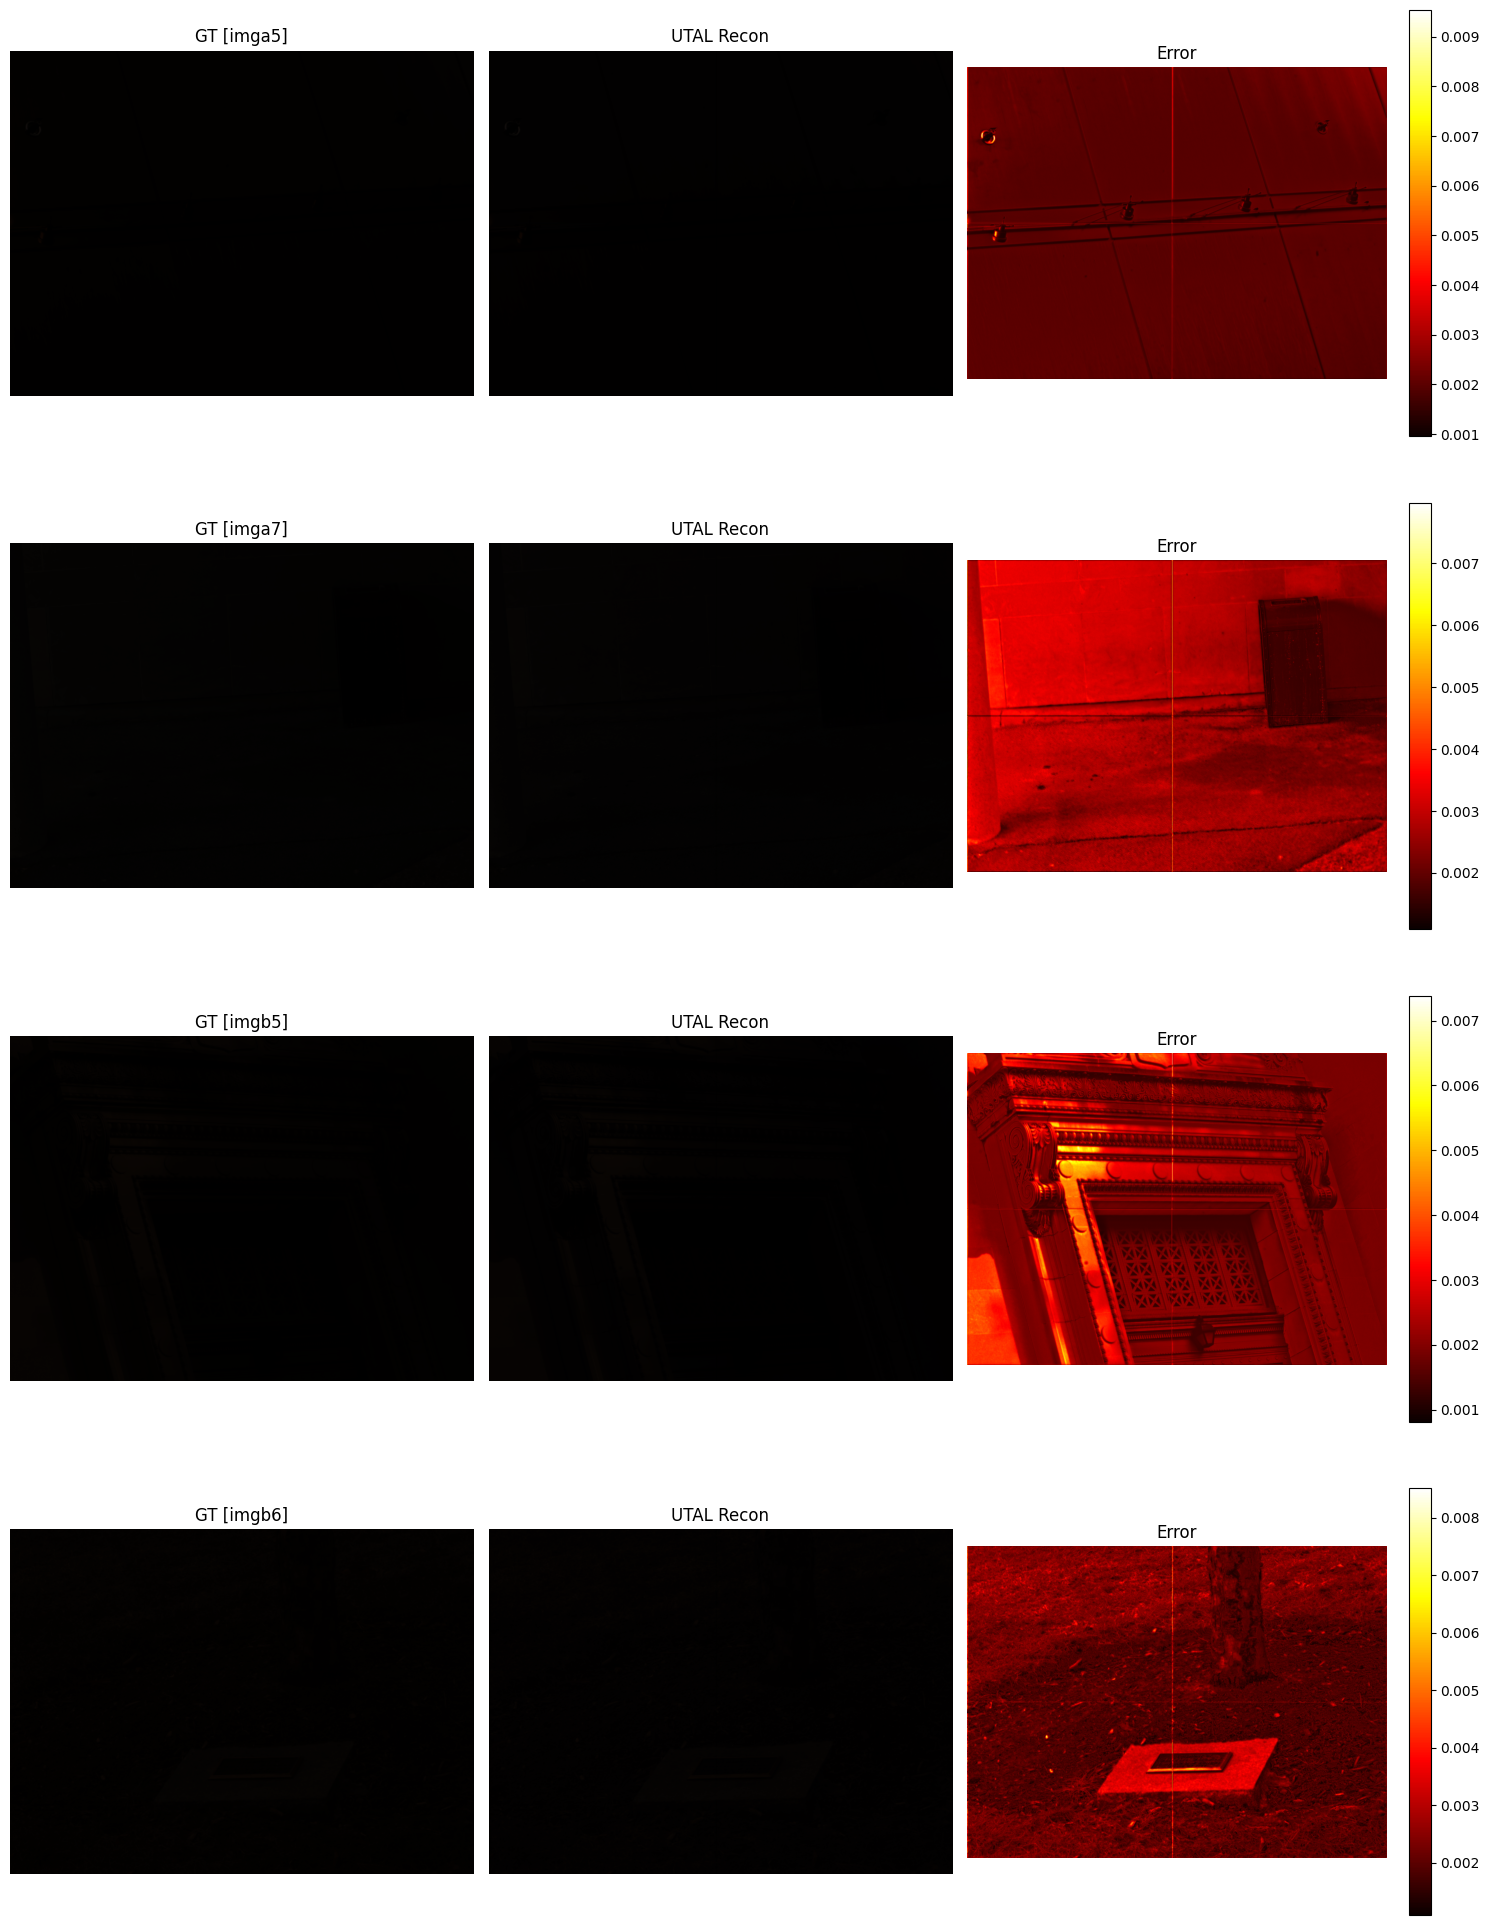

In [8]:
def to_rgb(h): return np.clip(h @ SRF, 0, 1)
n = min(4, len(results))
fig, ax = plt.subplots(n, 3, figsize=(15, 5*n))
if n == 1: ax = ax[np.newaxis, :]
for i in range(n):
    r = results[i]
    ax[i,0].imshow(to_rgb(r['gt']));   ax[i,0].set_title(f'GT [{r["name"]}]'); ax[i,0].axis('off')
    ax[i,1].imshow(to_rgb(r['pred'])); ax[i,1].set_title('UTAL Recon');        ax[i,1].axis('off')
    im = ax[i,2].imshow(np.abs(r['gt']-r['pred']).mean(-1), cmap='hot')
    ax[i,2].set_title('Error'); ax[i,2].axis('off')
    plt.colorbar(im, ax=ax[i,2], fraction=0.046)
plt.tight_layout(); plt.savefig('/kaggle/working/vis.png', dpi=150); plt.show()